# Data analysis of $S_{u u} \rightarrow \chi \chi \rightarrow W^+b \; W^+b$ decay

## Library imports

In [1]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

import uproot

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (7, 4)

## Data loading

In [7]:
signal_file_path = '/data/iduminic/diquark-analysis/full-hadro/sgn/chi-chi/wb-wb/136/yuu-020/m_chi-2000/136_8000_events.root'

with uproot.open(signal_file_path) as f:
    tree = f["Delphes"]

print(tree.keys())

['Event', 'Event/Event.fUniqueID', 'Event/Event.fBits', 'Event/Event.Number', 'Event/Event.ReadTime', 'Event/Event.ProcTime', 'Event/Event.ProcessID', 'Event/Event.MPI', 'Event/Event.Weight', 'Event/Event.CrossSection', 'Event/Event.CrossSectionError', 'Event/Event.Scale', 'Event/Event.AlphaQED', 'Event/Event.AlphaQCD', 'Event/Event.ID1', 'Event/Event.ID2', 'Event/Event.X1', 'Event/Event.X2', 'Event/Event.ScalePDF', 'Event/Event.PDF1', 'Event/Event.PDF2', 'Event_size', 'Weight', 'Weight/Weight.fUniqueID', 'Weight/Weight.fBits', 'Weight/Weight.Weight', 'Weight_size', 'Particle', 'Particle/Particle.fUniqueID', 'Particle/Particle.fBits', 'Particle/Particle.PID', 'Particle/Particle.Status', 'Particle/Particle.IsPU', 'Particle/Particle.M1', 'Particle/Particle.M2', 'Particle/Particle.D1', 'Particle/Particle.D2', 'Particle/Particle.Charge', 'Particle/Particle.Mass', 'Particle/Particle.E', 'Particle/Particle.Px', 'Particle/Particle.Py', 'Particle/Particle.Pz', 'Particle/Particle.P', 'Particle/

In [19]:
results = tree.arrays('Event/Event.CrossSection')['Event/Event.CrossSection']
results * 1000

<Array [[3.25e-07], [6.5e-07], ..., [0.000254]] type='100000 * var * float32'>

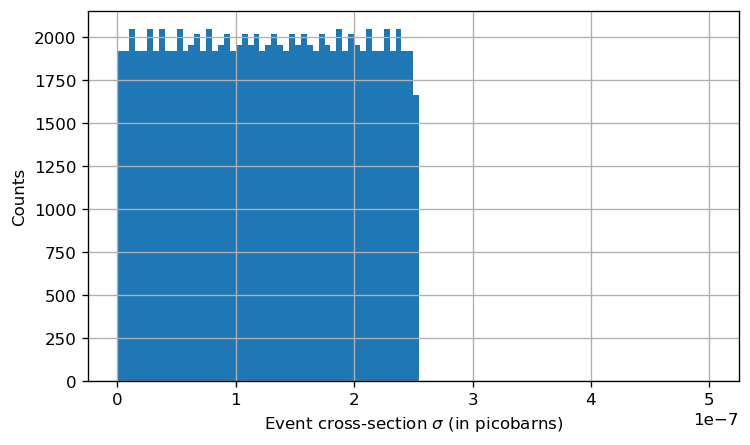

In [39]:
plt.hist(results, bins=100, range=(1e-12, 5e-7))
plt.xlabel("Event cross-section $\\sigma$ (in picobarns)")
plt.ylabel("Counts")
plt.grid()
plt.show()

In [15]:
f'{ak.mean(results) * 1000:E}'

'1.271425E-04'

## Jet variables analysis

### Jet multiplicity (number of jets)

In [3]:
jet_multiplicities = tree.arrays('Jet', library='ak')['Jet']
jet_multiplicities

<Array [8, 4, 7, 7, 7, 6, 6, 9, ..., 7, 7, 5, 8, 5, 4, 4] type='30000 * int32'>

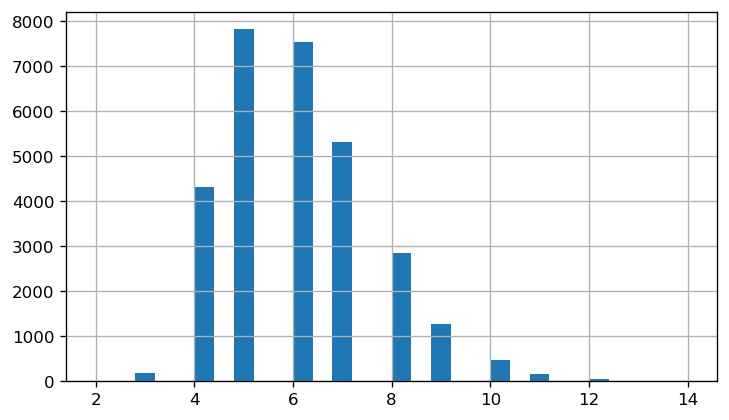

In [15]:
plt.hist(jet_multiplicities, bins=30)
plt.grid()
plt.show()

### Jet transverse momentum (momentum perpendicular to beam direction)

In [16]:
jet_pts = tree.arrays('Jet/Jet.PT', library='ak')['Jet/Jet.PT']
jet_pts

<Array [[952, 908, 387, ..., 129, 91.7, 32], ...] type='30000 * var * float32'>

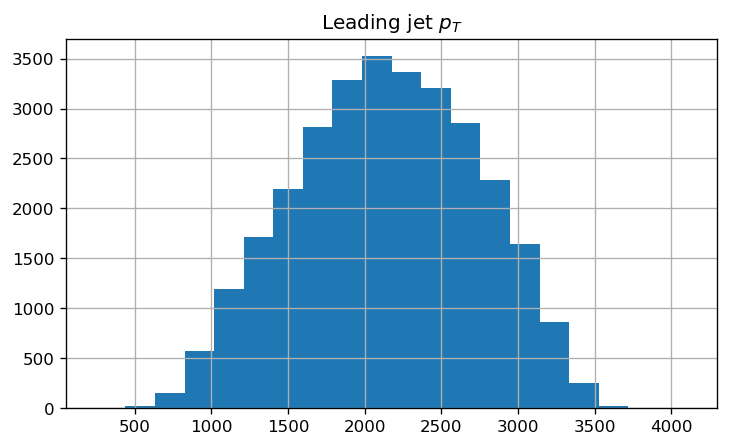

In [26]:
plt.title("Leading jet $p_T$")
plt.hist(jet_pts[:, 0], bins=20)
plt.grid()
plt.show()

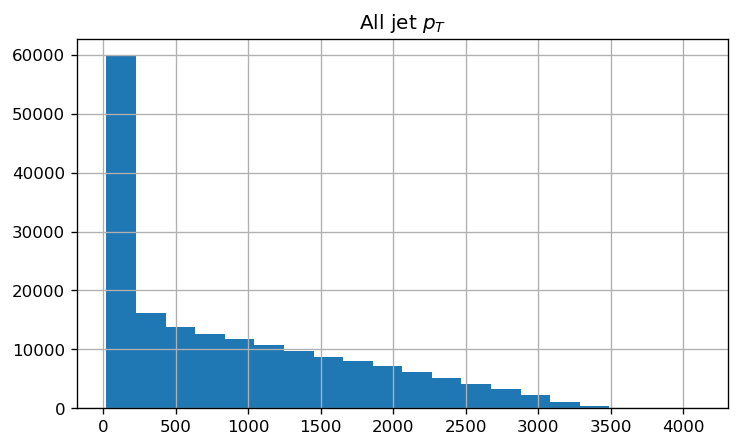

In [29]:
plt.title("All jet $p_T$")
plt.hist(ak.flatten(jet_pts), bins=20)
plt.grid()
plt.show()

### Jet rapidity $\eta$ (0 = perpendicular, $\pm \infty$ = along beam direction)

In [25]:
jet_etas = tree.arrays('Jet/Jet.Eta', library='ak')['Jet/Jet.Eta']
jet_etas

<Array [[-0.864, -0.768, ..., 1.69, 3.06], ...] type='30000 * var * float32'>

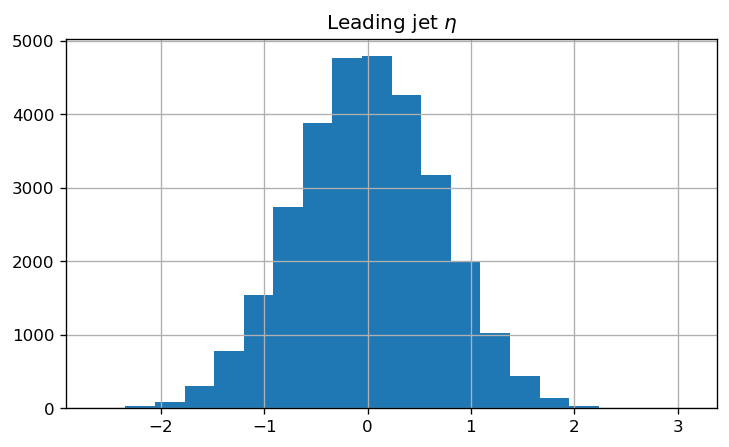

In [31]:
plt.title("Leading jet $\\eta$")
plt.hist(jet_etas[:, 0], bins=20)
plt.grid()
plt.show()

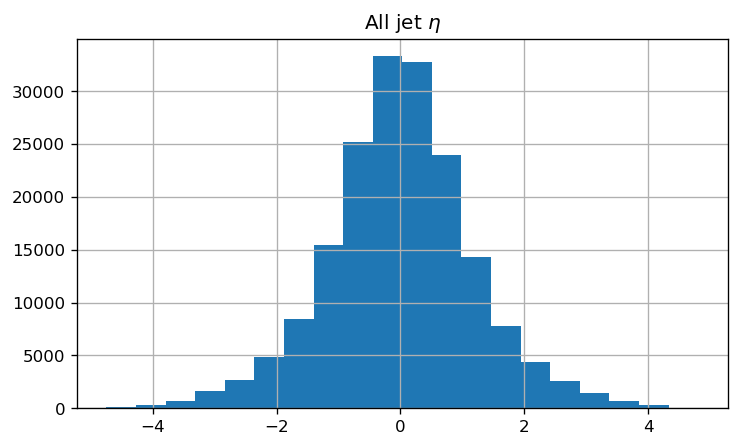

In [32]:
plt.title("All jet $\\eta$")
plt.hist(ak.flatten(jet_etas), bins=20)
plt.grid()
plt.show()

### Jet azimuthal angle

In [33]:
jet_phis = tree.arrays('Jet/Jet.Phi', library='ak')['Jet/Jet.Phi']
jet_phis

<Array [[-0.805, 2.5, ..., 0.214, 0.301], ...] type='30000 * var * float32'>

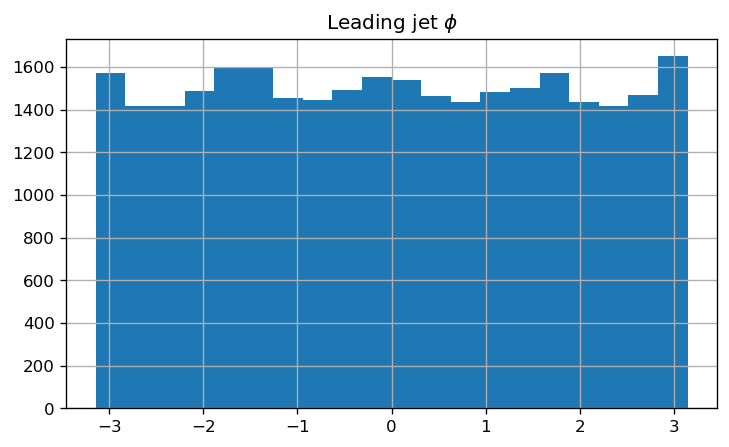

In [34]:
plt.title("Leading jet $\\phi$")
plt.hist(jet_phis[:, 0], bins=20)
plt.grid()
plt.show()

### Jet invariant mass

In [38]:
jet_masses = tree.arrays('Jet/Jet.Mass', library='ak')['Jet/Jet.Mass']
jet_masses

<Array [[87, 89.7, 24.4, ..., 12.9, 2.4], ...] type='30000 * var * float32'>

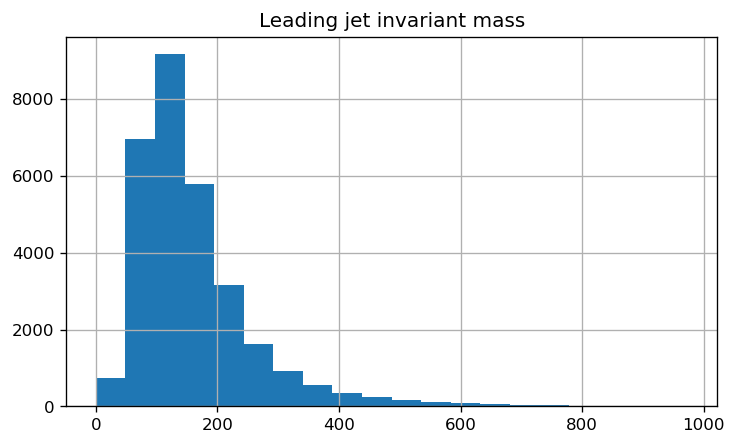

In [39]:
plt.title("Leading jet invariant mass")
plt.hist(jet_masses[:, 0], bins=20)
plt.grid()
plt.show()

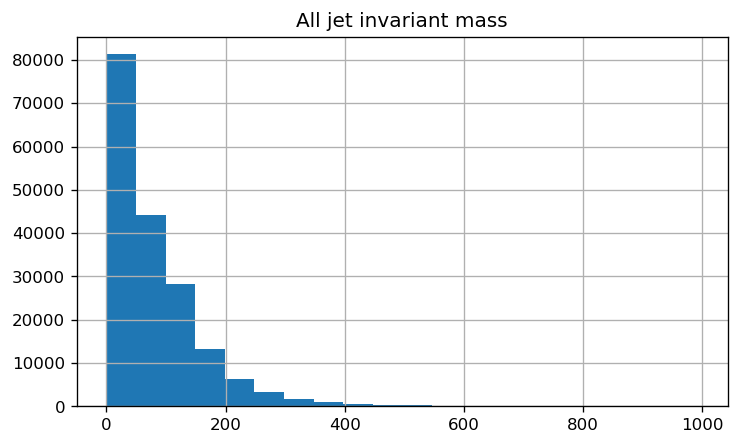

In [40]:
plt.title("All jet invariant mass")
plt.hist(ak.flatten(jet_masses), bins=20)
plt.grid()
plt.show()

### Sum of transverse momenta ($H_T$)

In [42]:
jet_hts = ak.sum(jet_pts, axis=-1)
jet_hts

<Array [3.14e+03, 5.99e+03, ..., 4.59e+03, 5.24e+03] type='30000 * float32'>

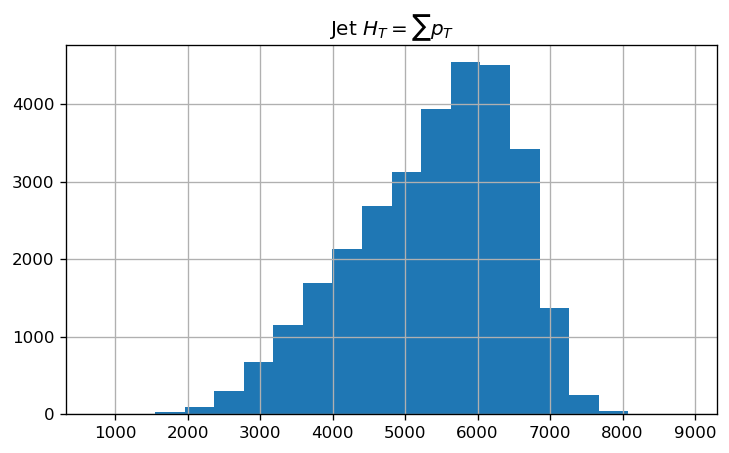

In [43]:
plt.title("Jet $H_T = \\sum p_T$")
plt.hist(jet_hts, bins=20)
plt.grid()
plt.show()